# 📡 TelecomAI — Multi-Agent Customer Service System

> **Built with:** LangGraph · GPT-4o-mini · text-embedding-3-small · FAISS Memory

---

### 🤖 Meet the Agents

| Agent | Name | Role |
|-------|------|------|
| 🟢 | **Nova** | Front-Desk Supervisor — Greets, verifies & routes |
| 🔵 | **Rajan** | Billing Specialist — Invoices, payments, plans |
| 🟡 | **Priya** | Technical Support — Network, SIM, connectivity |
| 🟣 | **Arjun** | Retention Specialist — Deals, discounts, cancellations |

### 🧠 Memory
- **Short-term:** Full conversation history per session
- **Long-term:** Ticket IDs, events & summaries in FAISS (text-embedding-3-small) — retrieved semantically each turn


## 🔧 Step 1 — Install Dependencies

In [ ]:
!pip install -q langgraph langchain langchain-openai langchain-community openai faiss-cpu tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 548.1/548.1 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


## 🔑 Step 2 — Set Your OpenAI API Key

In [ ]:
import os
import getpass

if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key: ")

print("API Key set!")

Enter your OpenAI API Key: ··········
API Key set!


## 📦 Step 3 — Imports

In [ ]:
import json
import random
from datetime import datetime
from typing import Annotated, Any, Dict, List, TypedDict

from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document

from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

print("All imports OK!")
print(f"Session: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

/usr/local/lib/python3.12/dist-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


All imports OK!
Session: 2026-05-16 08:52:44


## 🤖 Step 4 — Models & Memory Store

In [ ]:
# LLM
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)

# Embeddings
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

# FAISS Vector Store (bootstrapped with one doc)
memory_store = FAISS.from_documents(
    [Document(page_content="TelecomAI memory initialized.", metadata={"type": "init"})],
    embeddings
)

# Shared session state
session_state: Dict[str, Any] = {
    "customer_id": None,
    "account_name": None,
    "open_tickets": [],
    "plan": None,
    "verified": False,
}

print("GPT-4o-mini ready!")
print("text-embedding-3-small ready!")
print("FAISS memory store ready!")

GPT-4o-mini ready!
text-embedding-3-small ready!
FAISS memory store ready!


## 🧠 Step 5 — Memory Helpers

In [ ]:
def save_to_memory(content: str, metadata: dict):
    doc = Document(page_content=content, metadata=metadata)
    memory_store.add_documents([doc])

def recall_from_memory(query: str, k: int = 4) -> str:
    results = memory_store.similarity_search(query, k=k)
    relevant = [r for r in results if r.metadata.get("type") != "init"]
    if not relevant:
        return "No prior memory found."
    lines = []
    for r in relevant:
        meta_str = ", ".join(f"{mk}: {mv}" for mk, mv in r.metadata.items())
        lines.append(f"[{meta_str}] {r.page_content}")
    return "\n".join(lines)

def create_ticket(issue_type: str, description: str, agent: str) -> dict:
    ticket = {
        "ticket_id": f"TKT-{random.randint(10000, 99999)}",
        "issue_type": issue_type,
        "description": description,
        "status": "Open",
        "assigned_to": agent,
        "created_at": datetime.now().strftime("%Y-%m-%d %H:%M"),
        "customer_id": session_state.get("customer_id", "Unknown"),
    }
    session_state["open_tickets"].append(ticket)
    save_to_memory(
        f"Ticket {ticket['ticket_id']}: {issue_type} - {description}. Status: Open. Agent: {agent}.",
        {"type": "ticket", "ticket_id": ticket["ticket_id"], "status": "Open", "agent": agent}
    )
    return ticket

print("Memory helpers ready!")

Memory helpers ready!


## 🛠️ Step 6 — Dummy Telecom Tools

In [ ]:
# ── RAJAN: BILLING TOOLS ──────────────────────────────────────────────────────

@tool
def lookup_invoice(customer_id: str) -> str:
    """Look up the latest invoice for a customer."""
    dummy = {
        "C001": {"id": "INV-8821", "amount": "999 INR", "due": "2025-06-01", "status": "Unpaid"},
        "C002": {"id": "INV-9934", "amount": "1499 INR", "due": "2025-05-20", "status": "Paid"},
    }
    inv = dummy.get(customer_id, {"id": "INV-0000", "amount": "599 INR", "due": "2025-06-10", "status": "Unpaid"})
    result = f"Invoice {inv['id']} | Amount: {inv['amount']} | Due: {inv['due']} | Status: {inv['status']}"
    save_to_memory(f"Customer {customer_id} invoice: {result}", {"type": "billing", "customer_id": customer_id})
    return result

@tool
def process_payment(customer_id: str, amount: str) -> str:
    """Process a payment for the customer."""
    txn_id = f"TXN-{random.randint(100000, 999999)}"
    result = f"Payment of {amount} processed! Transaction ID: {txn_id}"
    save_to_memory(f"Customer {customer_id} paid {amount}. TXN: {txn_id}", {"type": "payment", "txn_id": txn_id, "customer_id": customer_id})
    return result

@tool
def upgrade_plan(customer_id: str, new_plan: str) -> str:
    """Upgrade or change the customer's telecom plan."""
    plans = {
        "basic": "399 INR/mo - 2GB/day",
        "standard": "699 INR/mo - 3GB/day",
        "premium": "999 INR/mo - Unlimited",
        "ultra": "1499 INR/mo - Unlimited + OTT"
    }
    details = plans.get(new_plan.lower(), f"{new_plan} - custom pricing")
    session_state["plan"] = new_plan.lower()
    result = f"Plan upgraded to {new_plan.upper()} ({details}) for customer {customer_id}."
    save_to_memory(result, {"type": "plan_change", "customer_id": customer_id, "plan": new_plan})
    return result

# ── PRIYA: TECH SUPPORT TOOLS ─────────────────────────────────────────────────

@tool
def run_network_diagnostic(customer_id: str, issue_type: str) -> str:
    """Run a network diagnostic for a customer's connection issue."""
    findings = [
        "Signal strength 72% - slight interference detected.",
        "Network congestion in your zone during peak hours (7PM-10PM).",
        "SIM card may need re-seating. Try removing and reinserting.",
        "Tower maintenance scheduled nearby. ETA: 2 hours.",
    ]
    finding = random.choice(findings)
    ticket = create_ticket("Network Issue", f"{issue_type} - Diagnostic: {finding}", "Priya")
    return f"Diagnostic complete. Finding: {finding}\nTicket raised: {ticket['ticket_id']}"

@tool
def reset_network_settings(customer_id: str) -> str:
    """Reset the customer's network settings remotely."""
    result = f"Network settings reset for customer {customer_id}. Please restart your device. Takes ~2 minutes."
    save_to_memory(result, {"type": "tech_action", "customer_id": customer_id, "action": "network_reset"})
    return result

@tool
def check_tower_status(area_code: str) -> str:
    """Check telecom tower status for a given area."""
    statuses = [
        "All towers operational.",
        "Partial outage - 1 tower under maintenance.",
        "Major outage - engineers dispatched."
    ]
    return f"Tower status for area {area_code}: {random.choice(statuses)}"

# ── ARJUN: RETENTION TOOLS ────────────────────────────────────────────────────

@tool
def get_available_offers(customer_id: str) -> str:
    """Fetch personalized retention offers for the customer."""
    offers = [
        "30% off next 3 months if you stay on Premium.",
        "Free 6-month OTT bundle (Netflix + Hotstar) with upgrade.",
        "Double data for 60 days at no extra charge.",
        "Cashback of 500 INR on next recharge.",
    ]
    selected = random.sample(offers, k=2)
    result = "\n".join(f"- {o}" for o in selected)
    save_to_memory(f"Offers shown to {customer_id}: {result}", {"type": "offer", "customer_id": customer_id})
    return result

@tool
def process_cancellation_request(customer_id: str, reason: str) -> str:
    """Log a cancellation or port-out request."""
    ticket = create_ticket("Cancellation Request", reason, "Arjun")
    return (
        f"Cancellation request logged. Ticket: {ticket['ticket_id']}\n"
        f"A retention specialist will call you within 24 hours."
    )

# ── NOVA: GENERAL TOOLS ───────────────────────────────────────────────────────

@tool
def verify_customer(customer_id: str, phone_last4: str) -> str:
    """Verify a customer's identity using their ID and last 4 digits of phone."""
    if len(phone_last4) == 4 and phone_last4.isdigit():
        session_state["customer_id"] = customer_id
        session_state["verified"] = True
        session_state["account_name"] = f"Customer-{customer_id}"
        save_to_memory(
            f"Customer {customer_id} verified at {datetime.now().strftime('%H:%M')}.",
            {"type": "verification", "customer_id": customer_id}
        )
        return f"Identity verified! Welcome, Customer {customer_id}."
    return "Verification failed. Please check your Customer ID and phone number."

@tool
def check_ticket_status(ticket_id: str) -> str:
    """Check the status of a support ticket."""
    for t in session_state["open_tickets"]:
        if t["ticket_id"] == ticket_id:
            return (
                f"Ticket {ticket_id}\n"
                f"  Issue: {t['issue_type']}\n"
                f"  Status: {t['status']}\n"
                f"  Agent: {t['assigned_to']}\n"
                f"  Created: {t['created_at']}"
            )
    mem = recall_from_memory(f"ticket {ticket_id}")
    if "No prior memory" not in mem:
        return f"From memory:\n{mem}"
    return f"Ticket {ticket_id} not found. Please check the ID."

print("All 9 tools ready!")
print("  Billing : lookup_invoice, process_payment, upgrade_plan")
print("  Tech    : run_network_diagnostic, reset_network_settings, check_tower_status")
print("  Retain  : get_available_offers, process_cancellation_request")
print("  General : verify_customer, check_ticket_status")

All 9 tools ready!
  Billing : lookup_invoice, process_payment, upgrade_plan
  Tech    : run_network_diagnostic, reset_network_settings, check_tower_status
  Retain  : get_available_offers, process_cancellation_request
  General : verify_customer, check_ticket_status


## 🕸️ Step 7 — Build the LangGraph

In [ ]:
BILLING_TOOLS = [lookup_invoice, process_payment, upgrade_plan]
TECH_TOOLS    = [run_network_diagnostic, reset_network_settings, check_tower_status]
RETAIN_TOOLS  = [get_available_offers, process_cancellation_request]
NOVA_TOOLS    = [verify_customer, check_ticket_status]
ALL_TOOLS     = NOVA_TOOLS + BILLING_TOOLS + TECH_TOOLS + RETAIN_TOOLS

nova_llm  = llm.bind_tools(ALL_TOOLS)
rajan_llm = llm.bind_tools(BILLING_TOOLS)
priya_llm = llm.bind_tools(TECH_TOOLS)
arjun_llm = llm.bind_tools(RETAIN_TOOLS)

# ── State ─────────────────────────────────────────────────────────────────────
class TelecomState(TypedDict):
    messages: Annotated[list, add_messages]
    current_agent: str
    memory_context: str

# ── System Prompts ────────────────────────────────────────────────────────────
def nova_system(ctx):
    return (
        "You are Nova, the friendly Front-Desk Supervisor at TelecomAI.\n"
        "Greet customers warmly, verify identity when needed, and route them to the right specialist.\n"
        "- Billing/payment/invoice/plan -> say: Connecting you to Rajan (Billing)\n"
        "- Network/connectivity/signal/tower -> say: Connecting you to Priya (Tech Support)\n"
        "- Cancel/port/offers/discount -> say: Connecting you to Arjun (Retention)\n"
        "- For sensitive requests, ask them to verify first using verify_customer.\n"
        "- Use check_ticket_status for any ticket IDs mentioned.\n"
        f"\nMEMORY:\n{ctx}\n\nSESSION: {json.dumps(session_state)}"
    )

def rajan_system(ctx):
    return (
        "You are Rajan, TelecomAI's Billing Specialist.\n"
        "Handle: invoices, payments, plan upgrades, billing disputes.\n"
        "Always run lookup_invoice before processing payments. Confirm amounts first.\n"
        f"\nMEMORY:\n{ctx}\n\nSESSION: {json.dumps(session_state)}"
    )

def priya_system(ctx):
    return (
        "You are Priya, TelecomAI's Technical Support Engineer.\n"
        "Handle: network issues, slow internet, dropped calls, SIM problems, tower outages.\n"
        "Always run a diagnostic first. Raise a ticket if unresolved and share the ticket ID.\n"
        f"\nMEMORY:\n{ctx}\n\nSESSION: {json.dumps(session_state)}"
    )

def arjun_system(ctx):
    return (
        "You are Arjun, TelecomAI's Retention Specialist.\n"
        "Handle: cancellations, port-out, exclusive deals, loyalty discounts.\n"
        "Always fetch personalized offers before discussing cancellation. Be empathetic.\n"
        f"\nMEMORY:\n{ctx}\n\nSESSION: {json.dumps(session_state)}"
    )

# ── Agent Nodes ───────────────────────────────────────────────────────────────
def nova_node(state):
    ctx = recall_from_memory(state["messages"][-1].content)
    resp = nova_llm.invoke([SystemMessage(content=nova_system(ctx))] + state["messages"])
    return {"messages": [resp], "current_agent": "nova", "memory_context": ctx}

def rajan_node(state):
    ctx = recall_from_memory(state["messages"][-1].content)
    resp = rajan_llm.invoke([SystemMessage(content=rajan_system(ctx))] + state["messages"])
    return {"messages": [resp], "current_agent": "rajan", "memory_context": ctx}

def priya_node(state):
    ctx = recall_from_memory(state["messages"][-1].content)
    resp = priya_llm.invoke([SystemMessage(content=priya_system(ctx))] + state["messages"])
    return {"messages": [resp], "current_agent": "priya", "memory_context": ctx}

def arjun_node(state):
    ctx = recall_from_memory(state["messages"][-1].content)
    resp = arjun_llm.invoke([SystemMessage(content=arjun_system(ctx))] + state["messages"])
    return {"messages": [resp], "current_agent": "arjun", "memory_context": ctx}

# ── Routing ───────────────────────────────────────────────────────────────────
def route_nova(state):
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tools"
    content = last.content.lower() if hasattr(last, "content") else ""
    if "rajan" in content or "billing" in content:
        return "rajan"
    if "priya" in content or "tech" in content:
        return "priya"
    if "arjun" in content or "retention" in content:
        return "arjun"
    return END

def specialist_route(state):
    last = state["messages"][-1]
    if hasattr(last, "tool_calls") and last.tool_calls:
        return "tools"
    return END

def after_tools(state):
    return state.get("current_agent", "nova")

# ── Compile ───────────────────────────────────────────────────────────────────
tool_node = ToolNode(tools=ALL_TOOLS)
builder = StateGraph(TelecomState)

builder.add_node("nova",  nova_node)
builder.add_node("rajan", rajan_node)
builder.add_node("priya", priya_node)
builder.add_node("arjun", arjun_node)
builder.add_node("tools", tool_node)

builder.add_edge(START, "nova")

builder.add_conditional_edges("nova", route_nova, {
    "tools": "tools", "rajan": "rajan",
    "priya": "priya", "arjun": "arjun", END: END
})
builder.add_conditional_edges("rajan", specialist_route, {"tools": "tools", END: END})
builder.add_conditional_edges("priya", specialist_route, {"tools": "tools", END: END})
builder.add_conditional_edges("arjun", specialist_route, {"tools": "tools", END: END})
builder.add_conditional_edges("tools", after_tools, {
    "nova": "nova", "rajan": "rajan", "priya": "priya", "arjun": "arjun"
})

graph = builder.compile()
print("LangGraph compiled!")

LangGraph compiled!


## 📊 Step 8 — Visualize the Graph

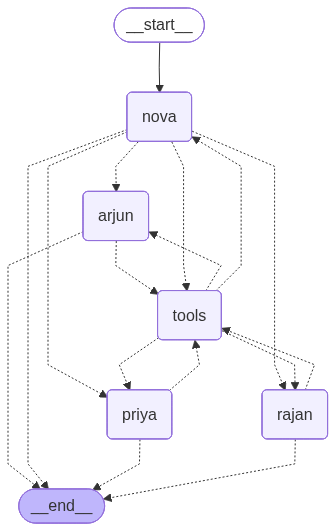

In [ ]:
try:
    from IPython.display import Image, display
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())

## 💬 Step 9 — Chat Interface

In [ ]:
AGENT_DISPLAY = {
    "nova":  "Nova  (Supervisor)",
    "rajan": "Rajan (Billing)",
    "priya": "Priya (Tech Support)",
    "arjun": "Arjun (Retention)",
}

conversation_history: List = []

def chat(user_input: str) -> str:
    global conversation_history
    if session_state.get("customer_id"):
        save_to_memory(
            f"User said: {user_input}",
            {"type": "conversation", "customer_id": session_state["customer_id"]}
        )
    conversation_history.append(HumanMessage(content=user_input))
    result = graph.invoke(
        {"messages": conversation_history, "current_agent": "nova", "memory_context": ""},
        config={"recursion_limit": 20}
    )
    final_msg = None
    for msg in reversed(result["messages"]):
        if isinstance(msg, AIMessage) and msg.content:
            final_msg = msg
            break
    conversation_history = result["messages"]
    agent = result.get("current_agent", "nova")
    label = AGENT_DISPLAY.get(agent, "Agent")
    text = final_msg.content if final_msg else "(no response)"
    print(f"\n{'='*60}")
    print(f"You   : {user_input}")
    print(f"{'-'*60}")
    print(f"{label}:")
    print(text)
    print(f"{'='*60}")
    return text

def reset_session():
    global conversation_history, session_state
    conversation_history = []
    session_state.update({"customer_id": None, "account_name": None,
                          "open_tickets": [], "plan": None, "verified": False})
    print("Session reset! (Vector memory preserved)")

def show_memory(query="customer ticket billing"):
    print("\nMemory recall:")
    print(recall_from_memory(query, k=5))

def show_state():
    print("\nSession State:")
    for k, v in session_state.items():
        if k != "open_tickets":
            print(f"  {k}: {v}")
    print(f"\nOpen Tickets ({len(session_state['open_tickets'])}):")
    for t in session_state["open_tickets"]:
        print(f"  [{t['ticket_id']}] {t['issue_type']} | {t['status']} | {t['assigned_to']}")

print("Chat ready!")
print("Commands: chat('msg') | reset_session() | show_memory() | show_state()")

Chat ready!
Commands: chat('msg') | reset_session() | show_memory() | show_state()


## 🎬 Step 10 — Demo Conversation

In [ ]:
chat("Hi, I need help with my account")


You   : Hi, I need help with my account
------------------------------------------------------------
Rajan (Billing):
To assist you better, could you please provide your customer ID or account name? This will help me look up your account information.


'To assist you better, could you please provide your customer ID or account name? This will help me look up your account information.'

In [ ]:
chat("My customer ID is C001 and my phone ends in 7890")


You   : My customer ID is C001 and my phone ends in 7890
------------------------------------------------------------
Rajan (Billing):
To assist you better, could you please provide your customer ID or account name? This will help me look up your account information.


'To assist you better, could you please provide your customer ID or account name? This will help me look up your account information.'

In [ ]:
chat("I want to check my latest invoice and pay it")


You   : I want to check my latest invoice and pay it
------------------------------------------------------------
Nova  (Supervisor):
Your latest invoice is as follows:

- **Invoice Number:** INV-8821
- **Amount:** 999 INR
- **Due Date:** June 1, 2025
- **Status:** Unpaid

However, I noticed that a payment of 0 INR was processed. Would you like to proceed with a payment for the full amount of 999 INR?


'Your latest invoice is as follows:\n\n- **Invoice Number:** INV-8821\n- **Amount:** 999 INR\n- **Due Date:** June 1, 2025\n- **Status:** Unpaid\n\nHowever, I noticed that a payment of 0 INR was processed. Would you like to proceed with a payment for the full amount of 999 INR?'

In [ ]:
chat("Also my internet has been very slow for 2 days")


You   : Also my internet has been very slow for 2 days
------------------------------------------------------------
Priya (Tech Support):
I've run a diagnostic on your internet connection. Here are the findings:

- **Signal Strength:** 72%
- **Interference:** Slight interference detected.

I've also raised a ticket for this issue. Here are the details:

- **Ticket ID:** TKT-59434
- **Status:** Open

If the issue persists or if you have any other questions, please let me know!


"I've run a diagnostic on your internet connection. Here are the findings:\n\n- **Signal Strength:** 72%\n- **Interference:** Slight interference detected.\n\nI've also raised a ticket for this issue. Here are the details:\n\n- **Ticket ID:** TKT-59434\n- **Status:** Open\n\nIf the issue persists or if you have any other questions, please let me know!"

In [ ]:
chat("What is the status of my latest ticket?")


You   : What is the status of my latest ticket?
------------------------------------------------------------
Priya (Tech Support):
Your latest ticket (Ticket ID: TKT-59434) is currently **Open**. It was raised for a network issue regarding slow internet, and it's being handled by me, Priya.

If you need further assistance or updates, feel free to ask!


"Your latest ticket (Ticket ID: TKT-59434) is currently **Open**. It was raised for a network issue regarding slow internet, and it's being handled by me, Priya.\n\nIf you need further assistance or updates, feel free to ask!"

In [ ]:
chat("I am thinking of cancelling my plan, the service is bad")


You   : I am thinking of cancelling my plan, the service is bad
------------------------------------------------------------
Nova  (Supervisor):
I understand your frustration, and I'm here to help. Before we proceed with the cancellation, I need to verify your identity again. Could you please provide the last 4 digits of your phone number?


"I understand your frustration, and I'm here to help. Before we proceed with the cancellation, I need to verify your identity again. Could you please provide the last 4 digits of your phone number?"

In [ ]:
chat("OK I will stay. Can you upgrade me to the Premium plan?")


You   : OK I will stay. Can you upgrade me to the Premium plan?
------------------------------------------------------------
Nova  (Supervisor):
Your plan has been successfully upgraded to the **Premium plan** (999 INR/month - Unlimited). 

If there's anything else you need or if you have any questions, feel free to ask!


"Your plan has been successfully upgraded to the **Premium plan** (999 INR/month - Unlimited). \n\nIf there's anything else you need or if you have any questions, feel free to ask!"

## 🧠 Step 11 — Test Cross-Session Memory

In [ ]:
reset_session()

Session reset! (Vector memory preserved)


In [ ]:
chat("Hi, I am customer C001. I called earlier about a network problem. Any updates?")


You   : Hi, I am customer C001. I called earlier about a network problem. Any updates?
------------------------------------------------------------
Priya (Tech Support):
Additionally, I understand that your internet has been slow for the past two days. Since we already have an open ticket for this issue, I will monitor the situation. If the problem persists, I can run another diagnostic or take further action. 

Please let me know if you would like me to proceed with that!


'Additionally, I understand that your internet has been slow for the past two days. Since we already have an open ticket for this issue, I will monitor the situation. If the problem persists, I can run another diagnostic or take further action. \n\nPlease let me know if you would like me to proceed with that!'

In [ ]:
show_memory("C001 network ticket billing")


Memory recall:
[type: billing, customer_id: C001] Customer C001 invoice: Invoice INV-8821 | Amount: 999 INR | Due: 2025-06-01 | Status: Unpaid
[type: payment, txn_id: TXN-304869, customer_id: C001] Customer C001 paid 0. TXN: TXN-304869
[type: plan_change, customer_id: C001, plan: Premium] Plan upgraded to PREMIUM (999 INR/mo - Unlimited) for customer C001.
[type: verification, customer_id: C001] Customer C001 verified at 08:53.
[type: ticket, ticket_id: TKT-59434, status: Open, agent: Priya] Ticket TKT-59434: Network Issue - slow internet - Diagnostic: Signal strength 72% - slight interference detected.. Status: Open. Agent: Priya.


## 📊 Step 12 — Inspect State & Tickets

In [ ]:
show_state()


Session State:
  customer_id: None
  account_name: None
  plan: None
  verified: False

Open Tickets (0):


## 🆓 Step 13 — Free Play / Interactive Loop

In [ ]:
print("Interactive mode  |  type 'exit' to stop, 'reset', 'memory', 'state' for commands")
print("=" * 60)
while True:
    try:
        user_input = input("\nYou: ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\nGoodbye!")
        break
    if not user_input:
        continue
    if user_input.lower() == "exit":
        print("Thanks for using TelecomAI!")
        break
    elif user_input.lower() == "reset":
        reset_session()
    elif user_input.lower() == "memory":
        show_memory()
    elif user_input.lower() == "state":
        show_state()
    else:
        chat(user_input)

Interactive mode  |  type 'exit' to stop, 'reset', 'memory', 'state' for commands

You: exit
Thanks for using TelecomAI!


In [ ]:
# ============================================================
# BEAUTIFUL MULTI AGENT DEBUG SYSTEM
# COMPLETE OBSERVABILITY VERSION
# ============================================================

# ============================================================
# INSTALL
# ============================================================

# !pip install -q langgraph langchain langchain-openai

# ============================================================
# IMPORTS
# ============================================================

import os
import json

from typing import TypedDict, Annotated

from google.colab import userdata

from langchain_openai import ChatOpenAI

from langchain_core.messages import (
    HumanMessage,
    SystemMessage
)

from langgraph.graph import (
    StateGraph,
    START,
    END
)

from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

# ============================================================
# OPENAI KEY
# ============================================================

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# ============================================================
# LOGGER UTILITIES
# ============================================================

WIDTH = 90

def divider():
    print("═" * WIDTH)

def big_section(title):

    print("\n")
    divider()
    print(f" {title}")
    divider()

def sub_section(title):

    print(f"\n▶ {title}")
    print("─" * WIDTH)

def success(msg):
    print(f"✅ {msg}")

def warning(msg):
    print(f"⚠️  {msg}")

def info(msg):
    print(f"ℹ️  {msg}")

def tool_log(msg):
    print(f"🛠️  {msg}")

def route_log(msg):
    print(f"🧭 {msg}")

def agent_log(msg):
    print(f"🤖 {msg}")

def llm_log(msg):
    print(f"🧠 {msg}")

def pretty_json(data):

    print(json.dumps(data, indent=4))

# ============================================================
# INITIALIZE LLM
# ============================================================

big_section("INITIALIZING LLM")

MODEL_NAME = "gpt-4o-mini"

info(f"Selected Model: {MODEL_NAME}")

base_llm = ChatOpenAI(
    model=MODEL_NAME,
    temperature=0
)

success("LLM Initialized Successfully")

# ============================================================
# TOOLS
# ============================================================

big_section("REGISTERING TOOLS")

def lookup_invoice(customer_id: str):
    """
    Lookup telecom invoice details.
    """

    big_section("TOOL EXECUTION")

    tool_log("lookup_invoice() called")

    sub_section("INPUT")

    print(customer_id)

    result = {
        "customer_id": customer_id,
        "invoice_amount": 1299,
        "status": "PENDING"
    }

    sub_section("OUTPUT")

    pretty_json(result)

    return result


def process_payment(amount: int):
    """
    Process telecom payment.
    """

    big_section("TOOL EXECUTION")

    tool_log("process_payment() called")

    sub_section("INPUT")

    print(amount)

    result = {
        "payment_status": "SUCCESS",
        "amount_paid": amount
    }

    sub_section("OUTPUT")

    pretty_json(result)

    return result


def run_network_diagnostic():
    """
    Run telecom network diagnostics.
    """

    big_section("TOOL EXECUTION")

    tool_log("run_network_diagnostic() called")

    result = {
        "signal_strength": "WEAK",
        "tower_status": "ACTIVE",
        "issue_found": True
    }

    sub_section("OUTPUT")

    pretty_json(result)

    return result


def check_tower_status(location: str):
    """
    Check telecom tower health status.
    """

    big_section("TOOL EXECUTION")

    tool_log("check_tower_status() called")

    sub_section("INPUT")

    print(location)

    result = {
        "location": location,
        "tower_status": "HEALTHY"
    }

    sub_section("OUTPUT")

    pretty_json(result)

    return result

# ============================================================
# TOOL GROUPS
# ============================================================

BILLING_TOOLS = [
    lookup_invoice,
    process_payment
]

TECH_TOOLS = [
    run_network_diagnostic,
    check_tower_status
]

ALL_TOOLS = BILLING_TOOLS + TECH_TOOLS

sub_section("Billing Tools")

for tool in BILLING_TOOLS:

    print(f"• {tool.__name__}")

sub_section("Technical Tools")

for tool in TECH_TOOLS:

    print(f"• {tool.__name__}")

# ============================================================
# BIND TOOLS
# ============================================================

big_section("BINDING TOOLS TO LLM")

billing_llm = base_llm.bind_tools(BILLING_TOOLS)

tech_llm = base_llm.bind_tools(TECH_TOOLS)

success("Tools Bound Successfully")

# ============================================================
# STATE
# ============================================================

class TelecomState(TypedDict):

    messages: Annotated[list, add_messages]

    current_agent: str

# ============================================================
# SYSTEM PROMPTS
# ============================================================

billing_prompt = """
You are Rajan, Telecom Billing Specialist.

Responsibilities:
- Billing support
- Invoice support
- Payment issues

Rules:
- Always lookup invoice first
- Confirm invoice before payment
"""

tech_prompt = """
You are Priya, Telecom Technical Engineer.

Responsibilities:
- Slow internet
- Network issues
- Tower issues

Rules:
- Always run diagnostics first
"""

# ============================================================
# DISPLAY MESSAGES
# ============================================================

def display_messages(messages):

    big_section("WHAT LLM IS SEEING")

    for idx, msg in enumerate(messages):

        sub_section(f"MESSAGE {idx+1}")

        print(f"TYPE: {type(msg).__name__}")

        if hasattr(msg, "content"):

            print("\nCONTENT:\n")

            print(msg.content)

        if hasattr(msg, "tool_calls"):

            print("\nTOOL CALLS:\n")

            print(msg.tool_calls)

# ============================================================
# BILLING NODE
# ============================================================

def billing_node(state):

    big_section("ENTERING BILLING NODE")

    agent_log("Agent: Rajan")

    messages = [
        SystemMessage(content=billing_prompt)
    ] + state["messages"]

    display_messages(messages)

    big_section("CALLING BILLING LLM")

    llm_log("Invoking GPT-4o-mini")

    response = billing_llm.invoke(messages)

    sub_section("RAW LLM RESPONSE")

    print(response)

    sub_section("TOOL DECISION")

    if response.tool_calls:

        success("LLM Decided To Use Tool")

        for tool_call in response.tool_calls:

            tool_log(f"Selected Tool: {tool_call['name']}")

            info(f"Arguments: {tool_call['args']}")

    else:

        warning("No Tool Was Called")

    return {
        "messages": [response],
        "current_agent": "billing"
    }

# ============================================================
# TECH NODE
# ============================================================

def tech_node(state):

    big_section("ENTERING TECH NODE")

    agent_log("Agent: Priya")

    messages = [
        SystemMessage(content=tech_prompt)
    ] + state["messages"]

    display_messages(messages)

    big_section("CALLING TECH LLM")

    llm_log("Invoking GPT-4o-mini")

    response = tech_llm.invoke(messages)

    sub_section("RAW LLM RESPONSE")

    print(response)

    sub_section("TOOL DECISION")

    if response.tool_calls:

        success("LLM Decided To Use Tool")

        for tool_call in response.tool_calls:

            tool_log(f"Selected Tool: {tool_call['name']}")

            info(f"Arguments: {tool_call['args']}")

    else:

        warning("No Tool Was Called")

    return {
        "messages": [response],
        "current_agent": "tech"
    }

# ============================================================
# MAIN ROUTER
# ============================================================

def router(state):

    big_section("ROUTER EXECUTION")

    last_message = state["messages"][-1]

    user_text = last_message.content.lower()

    sub_section("USER QUERY")

    print(user_text)

    # ========================================================
    # BILLING ROUTE
    # ========================================================

    if any(word in user_text for word in [
        "bill",
        "invoice",
        "payment"
    ]):

        route_log("Routing To BILLING Agent")

        return "billing"

    # ========================================================
    # TECH ROUTE
    # ========================================================

    elif any(word in user_text for word in [
        "internet",
        "network",
        "slow",
        "wifi"
    ]):

        route_log("Routing To TECH Agent")

        return "tech"

    # ========================================================
    # DEFAULT
    # ========================================================

    route_log("Default Route -> TECH")

    return "tech"

# ============================================================
# TOOL ROUTER
# ============================================================

def tool_router(state):

    big_section("CHECKING TOOL CALLS")

    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:

        success("Tool Call Detected")

        for tool_call in last_message.tool_calls:

            tool_log(f"Tool Selected: {tool_call['name']}")

            info(f"Arguments: {tool_call['args']}")

        return "tools"

    warning("No Tool Calls Found")

    return END

# ============================================================
# AFTER TOOL EXECUTION
# ============================================================

def after_tool_execution(state):

    big_section("RETURNING AFTER TOOL EXECUTION")

    current_agent = state["current_agent"]

    agent_log(f"Returning To: {current_agent}")

    return current_agent

# ============================================================
# TOOL NODE
# ============================================================

big_section("CREATING TOOL NODE")

tool_node = ToolNode(ALL_TOOLS)

success("Tool Node Created")

# ============================================================
# BUILD GRAPH
# ============================================================

big_section("BUILDING LANGGRAPH")

builder = StateGraph(TelecomState)

# ============================================================
# ADD NODES
# ============================================================

builder.add_node(
    "billing",
    billing_node
)

builder.add_node(
    "tech",
    tech_node
)

builder.add_node(
    "tools",
    tool_node
)

success("Nodes Added")

# ============================================================
# ENTRY ROUTING
# ============================================================

builder.add_conditional_edges(
    START,
    router,
    {
        "billing": "billing",
        "tech": "tech"
    }
)

# ============================================================
# BILLING -> TOOLS
# ============================================================

builder.add_conditional_edges(
    "billing",
    tool_router,
    {
        "tools": "tools",
        END: END
    }
)

# ============================================================
# TECH -> TOOLS
# ============================================================

builder.add_conditional_edges(
    "tech",
    tool_router,
    {
        "tools": "tools",
        END: END
    }
)

# ============================================================
# TOOLS -> AGENT
# ============================================================

builder.add_conditional_edges(
    "tools",
    after_tool_execution,
    {
        "billing": "billing",
        "tech": "tech"
    }
)

success("Graph Routes Connected")

# ============================================================
# COMPILE GRAPH
# ============================================================

big_section("COMPILING GRAPH")

graph = builder.compile()

success("Graph Compiled Successfully")

# ============================================================
# TEST QUERY
# ============================================================

big_section("USER QUERY")

query = "My internet is very slow"

print(query)

# ============================================================
# EXECUTE GRAPH
# ============================================================

big_section("STARTING GRAPH EXECUTION")

result = graph.invoke({
    "messages": [
        HumanMessage(content=query)
    ]
})

# ============================================================
# FINAL OUTPUT
# ============================================================

big_section("FINAL GRAPH OUTPUT")

for idx, msg in enumerate(result["messages"]):

    sub_section(f"FINAL MESSAGE {idx+1}")

    print(f"TYPE: {type(msg).__name__}")

    if hasattr(msg, "content"):

        print("\nCONTENT:\n")

        print(msg.content)

    if hasattr(msg, "tool_calls"):

        print("\nTOOL CALLS:\n")

        print(msg.tool_calls)

success("Execution Completed Successfully")



══════════════════════════════════════════════════════════════════════════════════════════
 INITIALIZING LLM
══════════════════════════════════════════════════════════════════════════════════════════
ℹ️  Selected Model: gpt-4o-mini
✅ LLM Initialized Successfully


══════════════════════════════════════════════════════════════════════════════════════════
 REGISTERING TOOLS
══════════════════════════════════════════════════════════════════════════════════════════

▶ Billing Tools
──────────────────────────────────────────────────────────────────────────────────────────
• lookup_invoice
• process_payment

▶ Technical Tools
──────────────────────────────────────────────────────────────────────────────────────────
• run_network_diagnostic
• check_tower_status


══════════════════════════════════════════════════════════════════════════════════════════
 BINDING TOOLS TO LLM
══════════════════════════════════════════════════════════════════════════════════════════
✅ Tools Bound Successfully


In [ ]:
# ============================================================
# PARALLEL MULTI AGENT SYSTEM
# WITH:
# ✅ Parallel Agent Execution
# ✅ Combined Responses
# ✅ Beautiful Structured Logs
# ✅ Execution Time Tracking
# ✅ Tool Calling Visibility
# ✅ ToolNode Visibility
# ============================================================

# ============================================================
# INSTALL
# ============================================================

# !pip install -q langgraph langchain langchain-openai

# ============================================================
# IMPORTS
# ============================================================

import os
import json
import time

from datetime import datetime

from typing import TypedDict, Annotated

from google.colab import userdata

from langchain_openai import ChatOpenAI

from langchain_core.messages import (
    HumanMessage,
    SystemMessage
)

from langgraph.graph import (
    StateGraph,
    START,
    END
)

from langgraph.graph.message import add_messages

from langgraph.prebuilt import ToolNode

# ============================================================
# OPENAI KEY
# ============================================================

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# ============================================================
# LOGGER UTILITIES
# ============================================================

WIDTH = 100

def divider():
    print("═" * WIDTH)

def big_section(title):

    print("\n")
    divider()
    print(f" {title}")
    divider()

def sub_section(title):

    print(f"\n▶ {title}")
    print("─" * WIDTH)

def success(msg):
    print(f"✅ {msg}")

def warning(msg):
    print(f"⚠️  {msg}")

def info(msg):
    print(f"ℹ️  {msg}")

def tool_log(msg):
    print(f"🛠️  {msg}")

def route_log(msg):
    print(f"🧭 {msg}")

def agent_log(msg):
    print(f"🤖 {msg}")

def llm_log(msg):
    print(f"🧠 {msg}")

def timer_log(start):

    elapsed = round(time.time() - start, 2)

    print(f"⏱️  Execution Time: {elapsed} sec")

def pretty_json(data):

    print(json.dumps(data, indent=4))

# ============================================================
# LLM
# ============================================================

big_section("INITIALIZING LLM")

MODEL_NAME = "gpt-4o-mini"

info(f"Model: {MODEL_NAME}")

base_llm = ChatOpenAI(
    model=MODEL_NAME,
    temperature=0
)

success("LLM Initialized")

# ============================================================
# TOOLS
# ============================================================

big_section("REGISTERING TOOLS")

def lookup_invoice(customer_id: str):
    """
    Lookup telecom invoice details.
    """

    start = time.time()

    big_section("TOOL EXECUTION")

    tool_log("lookup_invoice()")

    sub_section("INPUT")

    print(customer_id)

    result = {
        "customer_id": customer_id,
        "invoice_amount": 1299,
        "status": "PENDING"
    }

    sub_section("OUTPUT")

    pretty_json(result)

    timer_log(start)

    return result


def run_network_diagnostic():
    """
    Run telecom network diagnostics.
    """

    start = time.time()

    big_section("TOOL EXECUTION")

    tool_log("run_network_diagnostic()")

    result = {
        "signal_strength": "WEAK",
        "tower_status": "ACTIVE",
        "issue_found": True
    }

    sub_section("OUTPUT")

    pretty_json(result)

    timer_log(start)

    return result

# ============================================================
# TOOL GROUPS
# ============================================================

BILLING_TOOLS = [
    lookup_invoice
]

TECH_TOOLS = [
    run_network_diagnostic
]

ALL_TOOLS = BILLING_TOOLS + TECH_TOOLS

sub_section("Billing Tools")

for tool in BILLING_TOOLS:
    print(f"• {tool.__name__}")

sub_section("Tech Tools")

for tool in TECH_TOOLS:
    print(f"• {tool.__name__}")

# ============================================================
# BIND TOOLS
# ============================================================

big_section("BINDING TOOLS")

billing_llm = base_llm.bind_tools(BILLING_TOOLS)

tech_llm = base_llm.bind_tools(TECH_TOOLS)

success("Tools Bound Successfully")

# ============================================================
# STATE
# ============================================================

class TelecomState(TypedDict):

    messages: Annotated[list, add_messages]

    billing_response: str

    tech_response: str

# ============================================================
# SYSTEM PROMPTS
# ============================================================

billing_prompt = """
You are Rajan, Telecom Billing Agent.

Responsibilities:
- Invoice support
- Billing issues

Rules:
- Always lookup invoice first
"""

tech_prompt = """
You are Priya, Telecom Technical Agent.

Responsibilities:
- Slow internet
- Network issues

Rules:
- Always run diagnostics first
"""

combiner_prompt = """
You are Nova, Final Response Combiner Agent.

Responsibilities:
- Combine multiple agent outputs
- Generate final professional response
"""

# ============================================================
# DISPLAY MESSAGES
# ============================================================

def display_messages(messages):

    big_section("WHAT LLM IS SEEING")

    for idx, msg in enumerate(messages):

        sub_section(f"MESSAGE {idx+1}")

        print(f"TYPE: {type(msg).__name__}")

        if hasattr(msg, "content"):

            print("\nCONTENT:\n")

            print(msg.content)

# ============================================================
# BILLING NODE
# ============================================================

def billing_node(state):

    start = time.time()

    big_section("BILLING AGENT STARTED")

    agent_log("Agent: Rajan")

    messages = [
        SystemMessage(content=billing_prompt)
    ] + state["messages"]

    display_messages(messages)

    llm_log("Calling Billing LLM")

    response = billing_llm.invoke(messages)

    sub_section("RAW LLM RESPONSE")

    print(response)

    if response.tool_calls:

        sub_section("TOOL DECISION")

        for tc in response.tool_calls:

            tool_log(f"Tool Selected: {tc['name']}")

            info(f"Arguments: {tc['args']}")

    timer_log(start)

    return {
        "messages": [response],
        "billing_response": str(response.content)
    }

# ============================================================
# TECH NODE
# ============================================================

def tech_node(state):

    start = time.time()

    big_section("TECH AGENT STARTED")

    agent_log("Agent: Priya")

    messages = [
        SystemMessage(content=tech_prompt)
    ] + state["messages"]

    display_messages(messages)

    llm_log("Calling Tech LLM")

    response = tech_llm.invoke(messages)

    sub_section("RAW LLM RESPONSE")

    print(response)

    if response.tool_calls:

        sub_section("TOOL DECISION")

        for tc in response.tool_calls:

            tool_log(f"Tool Selected: {tc['name']}")

            info(f"Arguments: {tc['args']}")

    timer_log(start)

    return {
        "messages": [response],
        "tech_response": str(response.content)
    }

# ============================================================
# CUSTOM TOOL NODE
# ============================================================

class DebugToolNode(ToolNode):

    def invoke(self, state, config=None):

        start = time.time()

        big_section("TOOL NODE EXECUTION")

        last_message = state["messages"][-1]

        sub_section("TOOL CALLS RECEIVED")

        print(last_message.tool_calls)

        result = super().invoke(state, config)

        sub_section("TOOL NODE OUTPUT")

        print(result)

        timer_log(start)

        return result

# ============================================================
# COMBINER NODE
# ============================================================

def combiner_node(state):

    start = time.time()

    big_section("COMBINER AGENT")

    billing_output = state.get("billing_response", "")

    tech_output = state.get("tech_response", "")

    sub_section("AGENT OUTPUTS")

    print("\nBILLING OUTPUT:\n")
    print(billing_output)

    print("\nTECH OUTPUT:\n")
    print(tech_output)

    final_prompt = f"""
{combiner_prompt}

Billing Agent Output:
{billing_output}

Tech Agent Output:
{tech_output}

Generate one final customer response.
"""

    llm_log("Combining Agent Outputs")

    response = base_llm.invoke(final_prompt)

    sub_section("FINAL COMBINED RESPONSE")

    print(response.content)

    timer_log(start)

    return {
        "messages": [response]
    }

# ============================================================
# TOOL NODE
# ============================================================

tool_node = DebugToolNode(ALL_TOOLS)

# ============================================================
# BUILD GRAPH
# ============================================================

big_section("BUILDING GRAPH")

builder = StateGraph(TelecomState)

# ============================================================
# ADD NODES
# ============================================================

builder.add_node("billing", billing_node)

builder.add_node("tech", tech_node)

builder.add_node("tools", tool_node)

builder.add_node("combiner", combiner_node)

success("Nodes Added")

# ============================================================
# PARALLEL EXECUTION
# ============================================================

builder.add_edge(START, "billing")

builder.add_edge(START, "tech")

# ============================================================
# BOTH GO TO COMBINER
# ============================================================

builder.add_edge("billing", "combiner")

builder.add_edge("tech", "combiner")

# ============================================================
# END
# ============================================================

builder.add_edge("combiner", END)

# ============================================================
# COMPILE
# ============================================================

graph = builder.compile()

success("Graph Compiled Successfully")

# ============================================================
# TEST QUERY
# ============================================================

query = """
My internet is slow and I also want to check my invoice.
"""

big_section("USER QUERY")

print(query)

# ============================================================
# EXECUTION
# ============================================================

global_start = time.time()

big_section("STARTING GRAPH EXECUTION")

result = graph.invoke({
    "messages": [
        HumanMessage(content=query)
    ]
})

# ============================================================
# FINAL OUTPUT
# ============================================================

big_section("FINAL OUTPUT")

for idx, msg in enumerate(result["messages"]):

    sub_section(f"MESSAGE {idx+1}")

    print(type(msg).__name__)

    if hasattr(msg, "content"):

        print("\nCONTENT:\n")

        print(msg.content)

# ============================================================
# TOTAL EXECUTION TIME
# ============================================================

big_section("TOTAL EXECUTION TIME")

timer_log(global_start)

success("Execution Completed")



════════════════════════════════════════════════════════════════════════════════════════════════════
 INITIALIZING LLM
════════════════════════════════════════════════════════════════════════════════════════════════════
ℹ️  Model: gpt-4o-mini
✅ LLM Initialized


════════════════════════════════════════════════════════════════════════════════════════════════════
 REGISTERING TOOLS
════════════════════════════════════════════════════════════════════════════════════════════════════

▶ Billing Tools
────────────────────────────────────────────────────────────────────────────────────────────────────
• lookup_invoice

▶ Tech Tools
────────────────────────────────────────────────────────────────────────────────────────────────────
• run_network_diagnostic


════════════════════════════════════════════════════════════════════════════════════════════════════
 BINDING TOOLS
════════════════════════════════════════════════════════════════════════════════════════════════════
✅ Tools Bound Succes

In [ ]:
# ============================================================
# MULTIPLE TEST CASES
# ============================================================

test_queries = [

    # ========================================================
    # BOTH AGENTS SHOULD WORK IN PARALLEL
    # ========================================================

    """
    My internet is very slow and I also want to check my invoice.
    """,

    # ========================================================
    # BILLING FOCUSED
    # ========================================================

    """
    I want to verify my pending bill payment.
    """,

    # ========================================================
    # TECH FOCUSED
    # ========================================================

    """
    My WiFi is not working properly.
    """,

    # ========================================================
    # STRONG PARALLEL EXAMPLE
    # ========================================================

    """
    My network is unstable and I need invoice details for last month.
    """,

    # ========================================================
    # ANOTHER PARALLEL CASE
    # ========================================================

    """
    Internet speed is poor and payment confirmation is pending.
    """,

]

# ============================================================
# EXECUTE TESTS
# ============================================================

for idx, query in enumerate(test_queries):

    global_start = time.time()

    big_section(f"TEST CASE {idx+1}")

    print(query)

    big_section("GRAPH EXECUTION STARTED")

    result = graph.invoke({
        "messages": [
            HumanMessage(content=query)
        ]
    })

    # ========================================================
    # FINAL OUTPUT
    # ========================================================

    big_section("FINAL RESPONSE")

    for m in result["messages"]:

        if hasattr(m, "content"):

            print("\n")
            print(m.content)

    # ========================================================
    # TOTAL TIME
    # ========================================================

    big_section("TOTAL EXECUTION TIME")

    timer_log(global_start)

    print("\n\n")



════════════════════════════════════════════════════════════════════════════════════════════════════
 TEST CASE 1
════════════════════════════════════════════════════════════════════════════════════════════════════

    My internet is very slow and I also want to check my invoice.
    


════════════════════════════════════════════════════════════════════════════════════════════════════
 GRAPH EXECUTION STARTED
════════════════════════════════════════════════════════════════════════════════════════════════════


════════════════════════════════════════════════════════════════════════════════════════════════════
 BILLING AGENT STARTED
════════════════════════════════════════════════════════════════════════════════════════════════════
🤖 Agent: Rajan


════════════════════════════════════════════════════════════════════════════════════════════════════
 WHAT LLM IS SEEING
════════════════════════════════════════════════════════════════════════════════════════════════════

▶ MESSAGE 1
───